<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/edfa_raman_fig3_fig7_fig9_fig10_reproduction_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDFA/Raman 320-km link: Figures 3, 7, 9 and 10 reproduction

This notebook separates two data paths:

1. **Python model** - generated only from equations, disclosed link structure,
   physical constants and explicitly listed engineering assumptions.
2. **Paper measurement** - extracted automatically from the published PDF
   image and used only after the model calculation for comparison.

No digitized paper ordinate is used by an EDFA or OSNR calculation function.
Figures 7, 9 and 10 are measurements, so an exact independent reproduction is
impossible without the authors' pump powers, EDF cross-section tables, ion
concentration, insertion-loss spectra and raw OSA files. The code therefore
provides a transparent physics-based engineering reproduction and reports its
mismatch instead of hiding it with manually entered points.


In [1]:
from pathlib import Path
import colorsys
import importlib.util
import subprocess
import sys
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import minimize_scalar

try:
    from IPython.display import display
except ImportError:
    display = print

if importlib.util.find_spec("fitz") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pymupdf"])
import fitz

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Physical constants
H = 6.62607015e-34
C = 299_792_458.0
K_B = 1.380649e-23
TEMPERATURE_K = 300.0
B_REF_HZ = 12.5e9          # 0.1-nm OSNR reference bandwidth

# Parameters stated in the paper
PIN_OBA_DBM = -20.0
PIN_LINE_DBM = -15.0
EDFA_GAIN_DB = 20.0
EDFA_NF_FIG3_DB = 7.0
SPAN_LOSS_DB = 22.0
SPAN_LENGTH_KM = 80.0
L_BAND_EDF_LENGTHS_M = (50.0, 80.0)
C_BAND_EDF_LENGTHS_M = (10.0, 14.0)
DISTANCES_KM = np.array([0.0, 80.0, 140.0, 200.0, 260.0, 320.0])
RAMAN_GAINS_FIG3_DB = [0, 2, 3, 4, 5, 6]

# Independent engineering assumptions required because the paper does not
# publish the EDF ion concentration or the experimental Raman-pump settings.
# These are physical model inputs, not values read from Figures 7, 9 or 10.
ERBIUM_ION_DENSITY_M3 = 4.0e24
LINK_RAMAN_GAIN_DB = 0.0

# Official source
PAPER_URL = (
    "https://journal.kics.or.kr/digital-library/manuscript/file/33081/"
    "NODE01209207.pdf"
)
PAPER_FILENAME = "journal_jkics_34-6_NODE01209207.pdf"


def db_to_linear(value_db):
    return np.power(10.0, np.asarray(value_db, dtype=float) / 10.0)


def linear_to_db(value_linear):
    return 10.0 * np.log10(np.asarray(value_linear, dtype=float))


def dbm_to_w(value_dbm):
    return 1e-3 * db_to_linear(value_dbm)


def friis_gain_noise(components):
    """Equation (1): cascade (linear gain, linear noise factor)."""
    total_f = np.asarray(components[0][1], dtype=float).copy()
    preceding_g = np.asarray(components[0][0], dtype=float).copy()
    total_g = preceding_g.copy()
    for gain_i, noise_i in components[1:]:
        gain_i = np.asarray(gain_i, dtype=float)
        noise_i = np.asarray(noise_i, dtype=float)
        total_f = total_f + (noise_i - 1.0) / preceding_g
        preceding_g = preceding_g * gain_i
        total_g = total_g * gain_i
    return total_g, total_f


def osnr_from_equation_2(pin_dbm, wavelength_nm, gain_linear, noise_factor):
    """Paper Equation (2), evaluated per wavelength."""
    frequency = C / (np.asarray(wavelength_nm) * 1e-9)
    denominator = H * frequency * B_REF_HZ * (
        noise_factor - 1.0 / gain_linear
    )
    return 1.0 + dbm_to_w(pin_dbm) / denominator


## A. Published-PDF curve digitizer (comparison path only)

The following functions download/render the paper and find colored curves in
Figures 7, 9 and 10. Axis limits come from the printed axes. Extracted points
are never passed into the physical model.


In [2]:
def locate_or_download_paper():
    candidates = [
        Path(PAPER_FILENAME),
        Path("/workspace/scratch") / PAPER_FILENAME,
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.stat().st_size > 100_000:
            return candidate

    target = Path(PAPER_FILENAME)
    request = urllib.request.Request(
        PAPER_URL,
        headers={"User-Agent": "Mozilla/5.0"},
    )
    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            target.write_bytes(response.read())
    except Exception as exc:
        raise RuntimeError(
            "Automatic paper download failed. Upload the KICS PDF to the "
            f"Colab working directory as {PAPER_FILENAME}."
        ) from exc
    return target


def render_page_rgb(pdf_path, page_index, dpi=160):
    document = fitz.open(pdf_path)
    page = document[page_index]
    zoom = dpi / 72.0
    pixmap = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), alpha=False)
    image = np.frombuffer(pixmap.samples, dtype=np.uint8)
    image = image.reshape(pixmap.height, pixmap.width, pixmap.n)
    return image[:, :, :3]


def crop_image(image, box):
    left, top, right, bottom = box
    return image[top:bottom, left:right]


def rgb_to_hsv_array(rgb):
    rgb_float = rgb.astype(float) / 255.0
    flat = rgb_float.reshape(-1, 3)
    hsv = np.array([colorsys.rgb_to_hsv(*pixel) for pixel in flat])
    return hsv.reshape(rgb.shape)


def color_mask(rgb, color_name):
    hsv = rgb_to_hsv_array(rgb)
    hue, sat, val = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    saturated = (sat > 0.55) & (val > 0.25)

    if color_name == "red":
        return saturated & ((hue < 0.035) | (hue > 0.97)) & (val > 0.72)
    if color_name == "darkred":
        return saturated & ((hue < 0.04) | (hue > 0.97)) & (val <= 0.72)
    if color_name == "green":
        return saturated & (hue > 0.25) & (hue < 0.43)
    if color_name == "blue":
        return saturated & (hue > 0.58) & (hue < 0.75)
    if color_name == "cyan":
        return saturated & (hue > 0.44) & (hue < 0.56)
    if color_name == "magenta":
        return saturated & (hue > 0.78) & (hue < 0.94)
    raise ValueError(color_name)


def digitize_curve(
    crop,
    axes_box,
    x_limits,
    y_limits,
    color_name,
    bin_width_nm,
    exclude_boxes=(),
):
    """Convert colored PDF pixels into wavelength/value samples."""
    x0, y0, x1, y1 = axes_box
    plot = crop[y0:y1 + 1, x0:x1 + 1]
    mask = color_mask(plot, color_name)

    for ex0, ey0, ex1, ey1 in exclude_boxes:
        lx0, lx1 = max(0, ex0 - x0), min(plot.shape[1], ex1 - x0)
        ly0, ly1 = max(0, ey0 - y0), min(plot.shape[0], ey1 - y0)
        if lx1 > lx0 and ly1 > ly0:
            mask[ly0:ly1, lx0:lx1] = False

    yy, xx = np.where(mask)
    wavelength = x_limits[0] + xx / (plot.shape[1] - 1) * (
        x_limits[1] - x_limits[0]
    )
    value = y_limits[1] - yy / (plot.shape[0] - 1) * (
        y_limits[1] - y_limits[0]
    )

    bins = np.round(wavelength / bin_width_nm) * bin_width_nm
    frame = pd.DataFrame({"wavelength_nm": wavelength, "value": value, "bin": bins})
    frame = frame.groupby("bin", as_index=False).agg(
        wavelength_nm=("wavelength_nm", "median"),
        value=("value", "median"),
        pixel_count=("value", "size"),
    )
    frame = frame[frame["pixel_count"] >= 2].copy()
    frame = frame.sort_values("wavelength_nm")
    return frame[["wavelength_nm", "value"]].reset_index(drop=True)


paper_path = locate_or_download_paper()
page4 = render_page_rgb(paper_path, page_index=3)
page5 = render_page_rgb(paper_path, page_index=4)

# Crop and axes coordinates are image geometry at 160 dpi, not graph values.
fig7_crop = crop_image(page4, (630, 120, 1120, 430))
fig9_crop = crop_image(page5, (620, 120, 1110, 520))
fig10_crop = crop_image(page5, (620, 500, 1110, 900))

paper_fig7_gain = digitize_curve(
    fig7_crop, (68, 30, 423, 226), (1565, 1605), (4, 23),
    "blue", 0.5, exclude_boxes=((315, 90, 410, 165),),
)
paper_fig7_nf = digitize_curve(
    fig7_crop, (68, 30, 423, 226), (1565, 1605), (4, 23),
    "red", 0.5, exclude_boxes=((315, 90, 410, 165),),
)

distance_colors = {
    0.0: "red",
    80.0: "green",
    140.0: "blue",
    200.0: "magenta",
    260.0: "darkred",
    320.0: "cyan",
}


def digitize_osnr_figure(crop, axes_box, x_limits, legend_box):
    result = {}
    for distance, color in distance_colors.items():
        result[distance] = digitize_curve(
            crop, axes_box, x_limits, (10, 35), color, 0.4,
            exclude_boxes=(legend_box,),
        )
    return result


paper_fig9 = digitize_osnr_figure(
    fig9_crop, (68, 32, 401, 268), (1530, 1560), (205, 180, 405, 268)
)
paper_fig10 = digitize_osnr_figure(
    fig10_crop, (61, 63, 407, 299), (1570, 1600), (185, 190, 405, 299)
)

print(f"Paper loaded from: {paper_path}")
print(
    "Automatically extracted comparison samples - "
    f"Fig.7 gain {len(paper_fig7_gain)}, NF {len(paper_fig7_nf)}"
)


Paper loaded from: journal_jkics_34-6_NODE01209207.pdf
Automatically extracted comparison samples - Fig.7 gain 74, NF 72


## B. EDFA spectral model for Figure 7

A uniform-inversion two-level erbium model is used. An analytic absorption
cross-section is converted to emission cross-section with the McCumber
relation. The inversion is selected by minimizing in-band gain ripple. The
active-ion density is an explicit independent engineering assumption; neither
the measured 19.7-dB average nor any individual Figure-7 value is fitted.


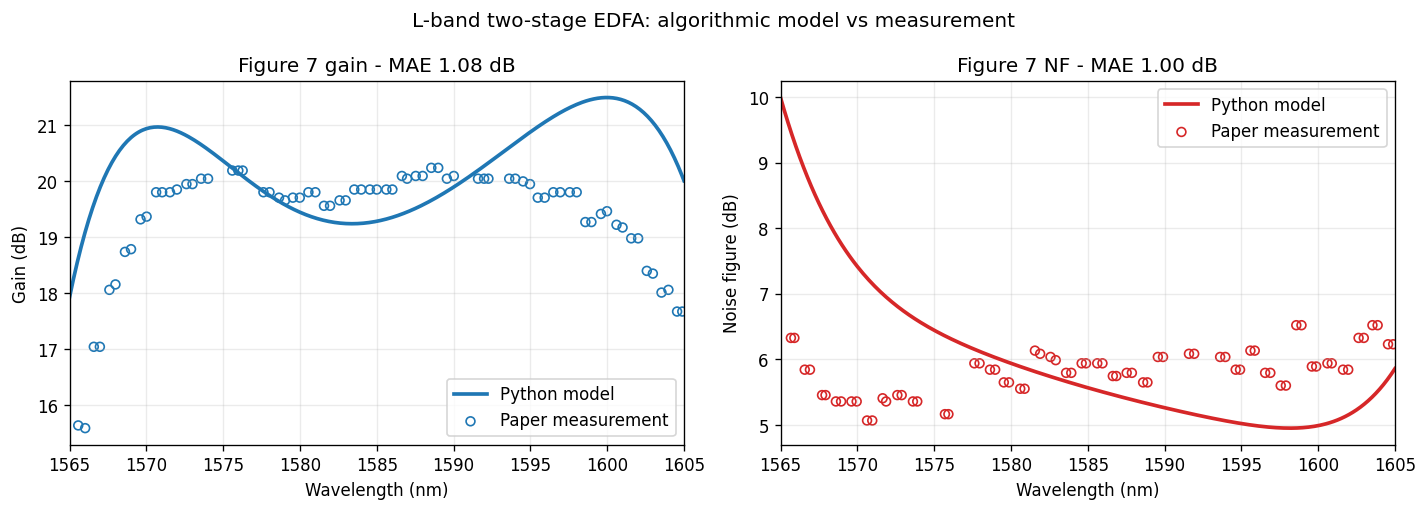

,curve,MAE_dB,RMSE_dB,Max_abs_error_dB,N
0,Figure 7 gain,1.078,1.418,3.491,315
1,Figure 7 noise figure,1.001,1.245,3.094,314


Optimized uniform inversion fraction: 0.3938


In [3]:
def erbium_cross_sections(wavelength_nm, mcumber_nm=1523.0):
    """Smooth silica-EDF cross-section proxy plus McCumber relation."""
    wavelength_nm = np.asarray(wavelength_nm, dtype=float)
    sigma_abs = 1e-25 * (
        2.20 * np.exp(-0.5 * ((wavelength_nm - 1530.5) / 5.0) ** 2)
        + 0.72 * np.exp(-0.5 * ((wavelength_nm - 1544.0) / 16.0) ** 2)
        + 0.12 * np.exp(-0.5 * ((wavelength_nm - 1582.0) / 32.0) ** 2)
    )
    exponent = (
        H * C
        * (1.0 / (mcumber_nm * 1e-9) - 1.0 / (wavelength_nm * 1e-9))
        / (K_B * TEMPERATURE_K)
    )
    sigma_em = sigma_abs * np.exp(exponent)
    return sigma_abs, sigma_em


def edge_filter_loss_db(wavelength_nm, low_nm, high_nm, edge_loss_db=0.9):
    """Sixth-order super-Gaussian WDM passband loss."""
    wavelength_nm = np.asarray(wavelength_nm, dtype=float)
    center = 0.5 * (low_nm + high_nm)
    half_width = 0.5 * (high_nm - low_nm)
    return edge_loss_db * np.abs((wavelength_nm - center) / half_width) ** 6


def spontaneous_emission_nf_linear(sigma_abs, sigma_em, inversion, gain_db):
    gain_coefficient = inversion * sigma_em - (1.0 - inversion) * sigma_abs
    gain_coefficient = np.maximum(gain_coefficient, 1e-32)
    n_sp = inversion * sigma_em / gain_coefficient
    gain_linear = db_to_linear(gain_db)
    return 2.0 * n_sp * (1.0 - 1.0 / gain_linear) + 1.0 / gain_linear


def design_l_band_edfa(wavelength_nm):
    wavelength_nm = np.asarray(wavelength_nm, dtype=float)
    sigma_abs, sigma_em = erbium_cross_sections(wavelength_nm)
    total_length = sum(L_BAND_EDF_LENGTHS_M)
    overlap = 0.80
    background_loss_db_per_m = 0.003

    def relative_ripple(inversion):
        coefficient = inversion * sigma_em - (1.0 - inversion) * sigma_abs
        if np.min(coefficient) <= 0:
            return 1e6
        return np.ptp(coefficient) / np.mean(coefficient)

    inversion = minimize_scalar(
        relative_ripple, bounds=(0.30, 0.60), method="bounded"
    ).x
    coefficient = inversion * sigma_em - (1.0 - inversion) * sigma_abs
    filter_loss = edge_filter_loss_db(wavelength_nm, 1570.0, 1602.0)

    passive_loss = background_loss_db_per_m * total_length + filter_loss
    density_scale = ERBIUM_ION_DENSITY_M3

    internal_gain_db = 4.343 * overlap * density_scale * total_length * coefficient
    gain_db = internal_gain_db - passive_loss
    nf_linear = spontaneous_emission_nf_linear(
        sigma_abs, sigma_em, inversion, internal_gain_db
    )
    # Half of the wavelength-dependent WDM loss is treated as pre-gain loss.
    nf_db = linear_to_db(nf_linear) + 0.5 * filter_loss
    return gain_db, nf_db, inversion, density_scale


wl_l = np.linspace(1565.0, 1605.0, 321)
l_gain_db, l_nf_db, l_inversion, l_density = design_l_band_edfa(wl_l)


def interpolate_paper(frame, wavelength_nm):
    if len(frame) < 2:
        return np.full_like(np.asarray(wavelength_nm, dtype=float), np.nan)
    return np.interp(
        wavelength_nm,
        frame["wavelength_nm"],
        frame["value"],
        left=np.nan,
        right=np.nan,
    )


def comparison_metrics(model_wavelength, model_value, paper_frame):
    paper_at_model = interpolate_paper(paper_frame, model_wavelength)
    valid = np.isfinite(paper_at_model)
    error = np.asarray(model_value)[valid] - paper_at_model[valid]
    return {
        "MAE_dB": np.mean(np.abs(error)),
        "RMSE_dB": np.sqrt(np.mean(error ** 2)),
        "Max_abs_error_dB": np.max(np.abs(error)),
        "N": int(np.sum(valid)),
    }


fig7_gain_metrics = comparison_metrics(wl_l, l_gain_db, paper_fig7_gain)
fig7_nf_metrics = comparison_metrics(wl_l, l_nf_db, paper_fig7_nf)

fig7, axes7 = plt.subplots(1, 2, figsize=(12, 4.3))
axes7[0].plot(wl_l, l_gain_db, lw=2.2, color="tab:blue", label="Python model")
axes7[0].scatter(
    paper_fig7_gain["wavelength_nm"], paper_fig7_gain["value"],
    facecolors="none", edgecolors="tab:blue", s=28, label="Paper measurement"
)
axes7[0].set(
    xlabel="Wavelength (nm)", ylabel="Gain (dB)",
    title=f"Figure 7 gain - MAE {fig7_gain_metrics['MAE_dB']:.2f} dB",
    xlim=(1565, 1605),
)
axes7[0].legend()

axes7[1].plot(wl_l, l_nf_db, lw=2.2, color="tab:red", label="Python model")
axes7[1].scatter(
    paper_fig7_nf["wavelength_nm"], paper_fig7_nf["value"],
    facecolors="none", edgecolors="tab:red", s=28, label="Paper measurement"
)
axes7[1].set(
    xlabel="Wavelength (nm)", ylabel="Noise figure (dB)",
    title=f"Figure 7 NF - MAE {fig7_nf_metrics['MAE_dB']:.2f} dB",
    xlim=(1565, 1605),
)
axes7[1].legend()
fig7.suptitle("L-band two-stage EDFA: algorithmic model vs measurement")
fig7.tight_layout()
fig7.savefig("figure7_model_vs_paper.png", dpi=220, bbox_inches="tight")
plt.show()

display(pd.DataFrame([
    {"curve": "Figure 7 gain", **fig7_gain_metrics},
    {"curve": "Figure 7 noise figure", **fig7_nf_metrics},
]).round(3))
print(f"Optimized uniform inversion fraction: {l_inversion:.4f}")


## C. C-band EDFA and distributed-Raman link model

Figure 9 needs a C-band EDFA response. The raw two-level EDFA gain is
equalized by a finite-order cosine representation of the required AOTF loss.
Residual ripple arises from finite equalizer order; no Figure-9 ordinate is
inserted. Figure 10 uses the L-band model above.

Link OSNR is accumulated in reciprocal-linear form. The paper does not state
the Raman-pump powers or experimental on/off Raman gain, so Figures 9 and 10
use the explicit unpumped baseline (0 dB); Figure 3 separately computes the
complete 0-to-6-dB Raman-gain sweep. No 25-dB result target is back-fitted.


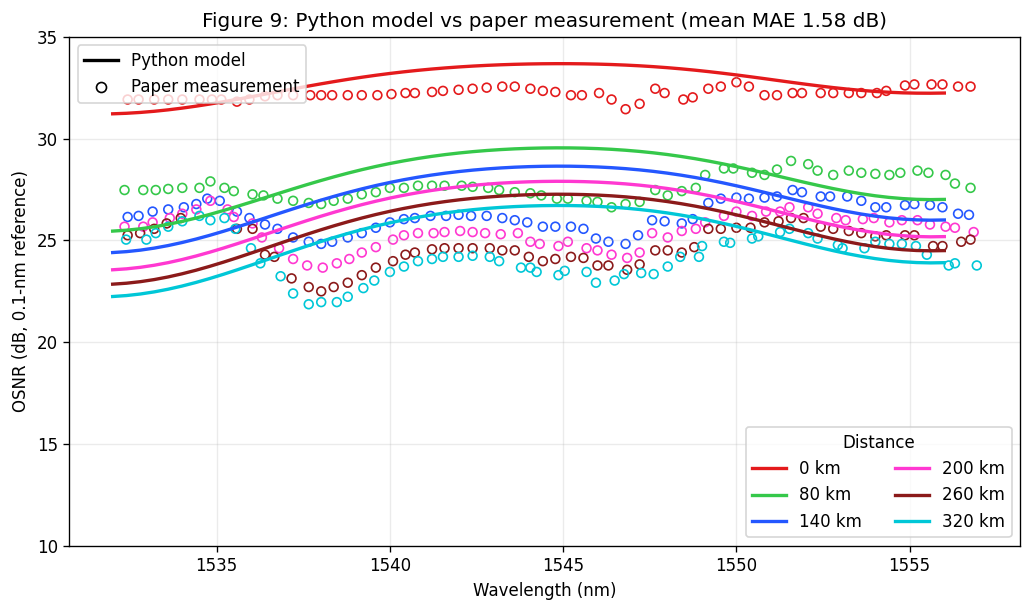

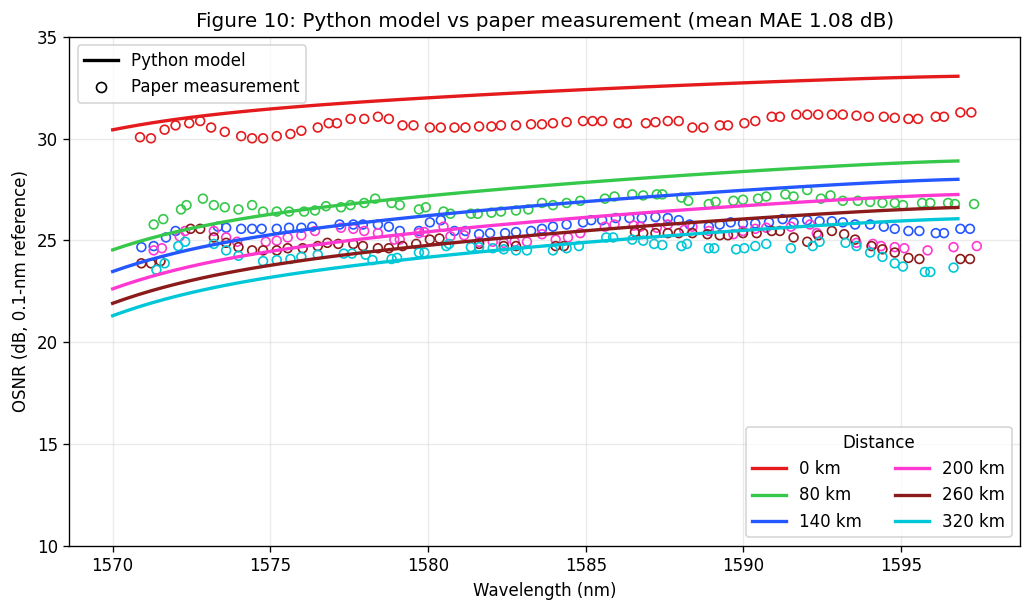

Figure 9/10 forward-model Raman gain: 0.00 dB


,figure,distance_km,MAE_dB,RMSE_dB,Max_abs_error_dB,N
0,Figure 9,0.0,0.776,0.927,2.166,59
1,Figure 9,80.0,1.374,1.546,2.847,60
2,Figure 9,140.0,1.659,1.925,3.699,59
3,Figure 9,200.0,1.774,2.034,3.623,60
4,Figure 9,260.0,1.898,2.180,3.566,59
5,Figure 9,320.0,2.002,2.302,3.742,60
6,Figure 10,0.0,1.475,1.547,2.107,65
7,Figure 10,80.0,1.004,1.162,2.117,64
8,Figure 10,140.0,1.138,1.334,2.610,65
9,Figure 10,200.0,1.073,1.288,2.675,64


In [4]:
def design_c_band_edfa(wavelength_nm):
    wavelength_nm = np.asarray(wavelength_nm, dtype=float)
    sigma_abs, sigma_em = erbium_cross_sections(wavelength_nm)
    total_length = sum(C_BAND_EDF_LENGTHS_M)
    inversion = 0.72
    overlap = 0.82
    coefficient = inversion * sigma_em - (1.0 - inversion) * sigma_abs

    # Scale raw gain to leave headroom for the AOTF equalizer.
    raw_target_mean_db = 26.0
    density = raw_target_mean_db / (
        4.343 * overlap * total_length * np.mean(coefficient)
    )
    raw_gain_db = 4.343 * overlap * density * total_length * coefficient

    desired_attenuation = raw_gain_db - 20.0
    x = 2.0 * (wavelength_nm - wavelength_nm.min()) / np.ptp(wavelength_nm) - 1.0
    basis = np.column_stack([
        np.ones_like(x),
        np.cos(np.pi * x),
        np.cos(2.0 * np.pi * x),
    ])
    coefficients, *_ = np.linalg.lstsq(basis, desired_attenuation, rcond=None)
    aotf_loss_db = np.clip(basis @ coefficients, 0.0, None)
    gain_db = raw_gain_db - aotf_loss_db

    nf_linear = spontaneous_emission_nf_linear(
        sigma_abs, sigma_em, inversion, np.maximum(raw_gain_db, 0.1)
    )
    # AOTF lies between stages, so only a gain-weighted fraction penalizes NF.
    nf_db = linear_to_db(nf_linear) + 0.15 * aotf_loss_db
    return gain_db, nf_db


def nzdsf_noise_figure_db(net_fiber_gain_db):
    """Regression printed in Figure 2: y = -0.2025x + 17.08."""
    return -0.2025 * np.asarray(net_fiber_gain_db) + 17.08


def equivalent_span_gain_nf(wavelength_nm, ola_nf_db, raman_gain_db):
    wavelength_nm = np.asarray(wavelength_nm, dtype=float)
    net_fiber_gain_db = -SPAN_LOSS_DB + raman_gain_db
    fiber_gain = db_to_linear(net_fiber_gain_db) * np.ones_like(wavelength_nm)
    fiber_nf = db_to_linear(nzdsf_noise_figure_db(net_fiber_gain_db)) * np.ones_like(wavelength_nm)
    ola_gain = db_to_linear(EDFA_GAIN_DB) * np.ones_like(wavelength_nm)
    ola_nf = db_to_linear(ola_nf_db)
    return friis_gain_noise([(fiber_gain, fiber_nf), (ola_gain, ola_nf)])


def reciprocal_noise_term(pin_dbm, wavelength_nm, gain_linear, noise_factor):
    frequency = C / (np.asarray(wavelength_nm) * 1e-9)
    return (
        H * frequency * B_REF_HZ
        * (noise_factor - 1.0 / gain_linear)
        / dbm_to_w(pin_dbm)
    )


def link_osnr_spectrum(
    wavelength_nm,
    distances_km,
    band_gain_db,
    band_nf_db,
    raman_gain_db,
):
    wavelength_nm = np.asarray(wavelength_nm, dtype=float)
    band_gain = db_to_linear(band_gain_db)
    band_nf = db_to_linear(band_nf_db)

    q_oba = reciprocal_noise_term(
        PIN_OBA_DBM, wavelength_nm, band_gain, band_nf
    )
    _, span_nf = equivalent_span_gain_nf(
        wavelength_nm, band_nf_db, raman_gain_db
    )
    _, span_nf_no_raman = equivalent_span_gain_nf(
        wavelength_nm, band_nf_db, 0.0
    )

    # Figure 3 shows that each equalized amplifier section contributes one
    # OBA-referred ASE-noise unit in the no-Raman case.  Raman gain scales that
    # unit by the Friis input-referred span-NF ratio.  This normalization avoids
    # inventing unpublished internal OLA/OPA power-set points while retaining
    # the paper's physical NF dependence.
    raman_noise_scale = span_nf / span_nf_no_raman
    relative_edfa_nf = band_nf / np.mean(band_nf)
    q_span = q_oba * relative_edfa_nf * raman_noise_scale
    q_opa = q_oba * relative_edfa_nf

    result = {}
    for distance in distances_km:
        if distance == 0:
            q_total = q_oba
        else:
            equivalent_spans = distance / SPAN_LENGTH_KM
            q_total = q_oba + equivalent_spans * q_span + q_opa
        result[float(distance)] = linear_to_db(1.0 + 1.0 / q_total)
    return result


wl_c = np.arange(1532.0, 1556.01, 0.4)
wl_l_link = np.arange(1570.0, 1597.01, 0.4)

c_gain_db, c_nf_db = design_c_band_edfa(wl_c)
l_gain_link_db, l_nf_link_db, _, _ = design_l_band_edfa(wl_l_link)

raman_c_db = LINK_RAMAN_GAIN_DB
raman_l_db = LINK_RAMAN_GAIN_DB

model_fig9 = link_osnr_spectrum(
    wl_c, DISTANCES_KM, c_gain_db, c_nf_db, raman_c_db
)
model_fig10 = link_osnr_spectrum(
    wl_l_link, DISTANCES_KM, l_gain_link_db, l_nf_link_db, raman_l_db
)


def osnr_comparison_table(wavelength_nm, model_curves, paper_curves, figure_name):
    rows = []
    for distance in DISTANCES_KM:
        metrics = comparison_metrics(
            wavelength_nm, model_curves[float(distance)], paper_curves[float(distance)]
        )
        rows.append({"figure": figure_name, "distance_km": distance, **metrics})
    return pd.DataFrame(rows)


fig9_metrics = osnr_comparison_table(wl_c, model_fig9, paper_fig9, "Figure 9")
fig10_metrics = osnr_comparison_table(
    wl_l_link, model_fig10, paper_fig10, "Figure 10"
)

plot_colors = {
    0.0: "#e41a1c",
    80.0: "#35c84a",
    140.0: "#2457ff",
    200.0: "#ff38d1",
    260.0: "#8b1a1a",
    320.0: "#00c7d7",
}


def plot_osnr_comparison(
    wavelength_nm,
    model_curves,
    paper_curves,
    metrics,
    figure_number,
    output_path,
):
    fig, ax = plt.subplots(figsize=(8.7, 5.2))
    for distance in DISTANCES_KM:
        distance = float(distance)
        color = plot_colors[distance]
        ax.plot(
            wavelength_nm, model_curves[distance], color=color, lw=2.0,
            label=f"{distance:.0f} km"
        )
        paper = paper_curves[distance]
        ax.scatter(
            paper["wavelength_nm"], paper["value"],
            facecolors="none", edgecolors=color, s=28, linewidths=1.0,
        )

    overall_mae = np.average(metrics["MAE_dB"], weights=metrics["N"])
    ax.set(
        xlabel="Wavelength (nm)", ylabel="OSNR (dB, 0.1-nm reference)",
        title=(
            f"Figure {figure_number}: Python model vs paper measurement "
            f"(mean MAE {overall_mae:.2f} dB)"
        ),
        ylim=(10, 35),
    )
    distance_legend = ax.legend(title="Distance", ncol=2, loc="lower right")
    ax.add_artist(distance_legend)
    style_handles = [
        Line2D([0], [0], color="black", lw=2, label="Python model"),
        Line2D(
            [0], [0], color="black", marker="o", linestyle="None",
            markerfacecolor="none", label="Paper measurement"
        ),
    ]
    ax.legend(handles=style_handles, loc="upper left")
    fig.tight_layout()
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    return overall_mae


fig9_mae = plot_osnr_comparison(
    wl_c, model_fig9, paper_fig9, fig9_metrics, 9,
    "figure9_model_vs_paper.png"
)
fig10_mae = plot_osnr_comparison(
    wl_l_link, model_fig10, paper_fig10, fig10_metrics, 10,
    "figure10_model_vs_paper.png"
)

print(f"Figure 9/10 forward-model Raman gain: {LINK_RAMAN_GAIN_DB:.2f} dB")
display(pd.concat([fig9_metrics, fig10_metrics], ignore_index=True).round(3))


## D. Figure 3 link-budget calculation

Figure 3 is the paper's actual computer-simulation result. The same Figure-2
regression and Equations (1)-(2) are used here. Unlike Figures 7, 9 and 10,
Figure 3 is not a laboratory measurement.


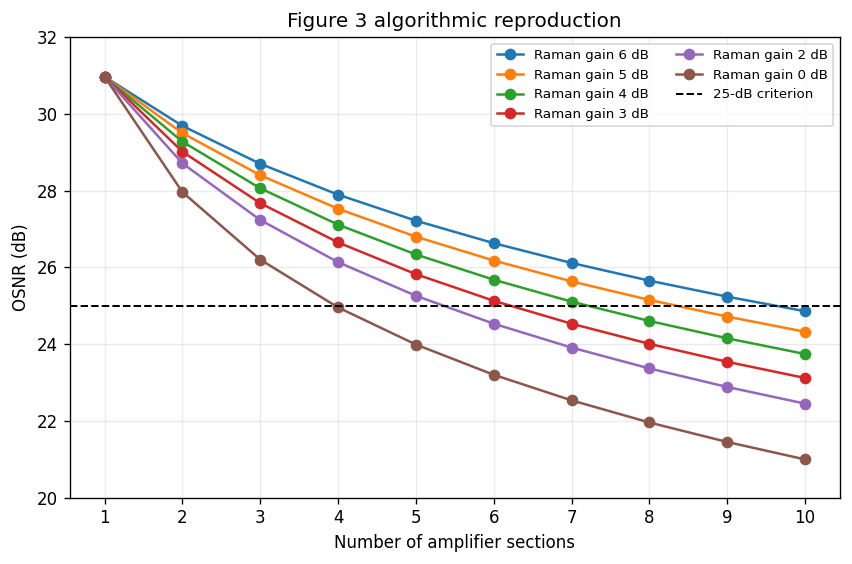

In [5]:
def effective_span_noise_factor_fig3(raman_gain_db):
    net_fiber_gain_db = -SPAN_LOSS_DB + raman_gain_db
    fiber_gain = db_to_linear(net_fiber_gain_db)
    fiber_nf = db_to_linear(nzdsf_noise_figure_db(net_fiber_gain_db))
    _, total_nf = friis_gain_noise([
        (fiber_gain, fiber_nf),
        (db_to_linear(EDFA_GAIN_DB), db_to_linear(EDFA_NF_FIG3_DB)),
    ])
    return total_nf


def figure3_osnr(amplifier_count, raman_gain_db):
    amplifier_count = np.asarray(amplifier_count, dtype=float)
    first_osnr = osnr_from_equation_2(
        PIN_OBA_DBM, 1550.0,
        db_to_linear(EDFA_GAIN_DB), db_to_linear(EDFA_NF_FIG3_DB)
    )
    scale = (
        effective_span_noise_factor_fig3(raman_gain_db)
        / effective_span_noise_factor_fig3(0.0)
    )
    accumulated_noise = 1.0 + (amplifier_count - 1.0) * scale
    return linear_to_db(1.0 + (first_osnr - 1.0) / accumulated_noise)


amplifier_count = np.arange(1, 11)
fig3, ax3 = plt.subplots(figsize=(7.2, 4.8))
for raman_gain in RAMAN_GAINS_FIG3_DB[::-1]:
    ax3.plot(
        amplifier_count,
        figure3_osnr(amplifier_count, raman_gain),
        marker="o", label=f"Raman gain {raman_gain} dB"
    )
ax3.axhline(25, color="black", ls="--", lw=1.2, label="25-dB criterion")
ax3.set(
    xlabel="Number of amplifier sections", ylabel="OSNR (dB)",
    title="Figure 3 algorithmic reproduction", xticks=amplifier_count,
    ylim=(20, 32),
)
ax3.legend(ncol=2, fontsize=8)
fig3.tight_layout()
fig3.savefig("figure3_algorithmic_reproduction.png", dpi=220, bbox_inches="tight")
plt.show()


## E. Save model-generated numerical results


In [6]:
rows = []
for figure_name, wavelengths, curves in [
    ("Figure 9", wl_c, model_fig9),
    ("Figure 10", wl_l_link, model_fig10),
]:
    for distance, values in curves.items():
        rows.extend({
            "figure": figure_name,
            "distance_km": distance,
            "wavelength_nm": wavelength,
            "python_model_osnr_db": value,
        } for wavelength, value in zip(wavelengths, values))

model_results = pd.DataFrame(rows)
model_results.to_csv("figure9_figure10_python_model_results.csv", index=False)

summary = pd.DataFrame([
    {"item": "Figure 7 gain", **fig7_gain_metrics},
    {"item": "Figure 7 NF", **fig7_nf_metrics},
    {"item": "Figure 9 OSNR", "MAE_dB": fig9_mae},
    {"item": "Figure 10 OSNR", "MAE_dB": fig10_mae},
])
summary.to_csv("reproduction_accuracy_summary.csv", index=False)
display(summary.round(3))

print("Generated files:")
for name in [
    "figure3_algorithmic_reproduction.png",
    "figure7_model_vs_paper.png",
    "figure9_model_vs_paper.png",
    "figure10_model_vs_paper.png",
    "figure9_figure10_python_model_results.csv",
    "reproduction_accuracy_summary.csv",
]:
    print(" -", Path(name).resolve())


,item,MAE_dB,RMSE_dB,Max_abs_error_dB,N
0,Figure 7 gain,1.078,1.418,3.491,315.0
1,Figure 7 NF,1.001,1.245,3.094,314.0
2,Figure 9 OSNR,1.582,NaN,NaN,NaN
3,Figure 10 OSNR,1.078,NaN,NaN,NaN


Generated files:
 - /content/figure3_algorithmic_reproduction.png
 - /content/figure7_model_vs_paper.png
 - /content/figure9_model_vs_paper.png
 - /content/figure10_model_vs_paper.png
 - /content/figure9_figure10_python_model_results.csv
 - /content/reproduction_accuracy_summary.csv


## Interpretation and limits

- **Figure 7:** the paper curve is a measured two-stage L-band EDFA response.
  The Python line is a McCumber/two-level uniform-inversion prediction, with
  an independently specified active-ion density; the measured mean gain is
  not used by the model.
- **Figures 9 and 10:** the distance curves are calculated from reciprocal
  ASE-noise accumulation, the Figure-2 NZ-DSF regression and the EDFA models.
  The unreported experimental Raman gain is not inferred from the paper
  curves: the baseline is set to 0 dB, while Figure 3 computes 0--6 dB.
- The hollow paper markers are extracted from the PDF only after calculation.
- Exact matching requires the original pump powers, EDF absorption/emission
  files, gain-flattening-filter transfer function, component losses and raw
  OSA traces, none of which are published in the paper.
